# 04. 검증과 feature 선택 (계획 10~11단계)

모든 후보를 **갭 기준선 대비 Δscore**로, 세 가지 검증에서 잼.

| 검증 | 흉내 내는 것 |
|---|---|
| walk-forward | 미래 구간 |
| 종목 holdout | 처음 보는 종목 |
| 시간 + 종목 holdout | 실제 채점 (미래 × 처음 보는 종목) |

모델은 HistGradientBoosting 회귀로 당일 수익률(%)을 예측하고, `label_of(k × 예측값)`으로 label을 정함.
k는 학습 구간의 마지막 20%에서 고름. 갭 규칙(`label_of(k × 갭)`)과 결정 방식이 같아서 공정하게 비교됨.

분류 확률에서 기대 벌점이 가장 작은 label을 고르는 방식(`decision="cost"`)은 쓰지 않음.
00 노트북 5절에서 본 것처럼 급등락 예측이 분모 E를 키워 점수를 올리는데, 이 방식은 그 효과를 무시해서
급등락을 너무 아낌 (2026-01 기준 한 구간에서 0.43 vs 회귀 방식 0.51).

전체 실행은 약 3~5분 걸림.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import eda_utils as U

U.setup_plot()
pd.set_option("display.float_format", "{:.4f}".format)

panel, cal = U.load_all(reddit=True)
acts = [c for c in panel.columns if c.startswith("act_")]
base = ["gap_pct", "abs_gap", "zgap", "gap_rank"]
groups = {
    "변동성": ["vol5", "vol20", "atr14", "big_rate60", "big_d0", "ret_d0"],
    "시장/잔차 갭": ["mkt_gap", "resid_gap", "beta60", "post_ret", "pre_ret"],
    "실적": ["earn", "surp_sign", "surp_abs", "surp_pct_w"],
    "애널리스트": ["an_n", "an_up", "an_down", "an_tgt_chg"],
    "뉴스": ["news_n_abn", "tone_mean", "tone_min", "tone_max", "tone_std", "tone_neg_tail", "tone_pos_tail"],
    "Reddit": ["mentions_abn", *acts],
}
splits = U.walk_forward(panel) + U.symbol_holdout(panel) + U.time_symbol_holdout(panel)
pd.DataFrame([(n, tr.sum(), te.sum()) for n, tr, te in splits], columns=["split", "학습 행", "평가 행"])

,split,학습 행,평가 행
0,wf 2025-07,10500,4200
1,wf 2025-11,14800,4000
2,wf 2026-03,18850,4100
3,sym 0,20880,5220
4,sym 1,20880,5220
5,sym 2,20880,5220
6,sym 3,20880,5220
7,sym 4,20880,5220
8,time+sym 0,13520,1750
9,time+sym 1,13520,1750


## 1. 갭 기준선부터

갭 규칙(머신러닝 없음)과 갭 feature만 쓴 회귀 모델의 점수를 먼저 봄. 이후 모든 Δscore는 회귀 모델 기준임.
갭 규칙이 회귀 모델보다 높으면, 모델이 갭 하나를 쓰는 것보다 못하다는 뜻이라 feature를 더하기 전에 먼저 짚어야 함.

In [2]:
rows = []
for name, tr, te in splits:
    train, test = panel[tr].dropna(subset=["gap_pct"]), panel[te]
    k, _ = U.fit_gap_rule(train)
    rule = U.score_ext(test["label"], U.gap_rule(test["gap_pct"], k))
    model = U.fit_eval(panel[tr], test, base)
    rows.append({"split": name, "k": k, "갭 규칙": rule["score"], "갭 회귀 모델": model["score"],
                 "모델 k": model["k"], "모델 flip": model["flip_rate"]})
pd.DataFrame(rows)

,split,k,갭 규칙,갭 회귀 모델,모델 k,모델 flip
0,wf 2025-07,4.7500,0.4132,0.3995,6.2500,0.1197
1,wf 2025-11,4.2500,0.3989,0.3856,3.2500,0.1027
2,wf 2026-03,4.5000,0.5393,0.5368,7.7500,0.2006
3,sym 0,6.2500,0.5047,0.4981,6.7500,0.2197
4,sym 1,5.2500,0.4922,0.4972,4.7500,0.1487
5,sym 2,6.5000,0.4558,0.4467,6.5000,0.2054
6,sym 3,5.2500,0.4441,0.4315,6.7500,0.1849
7,sym 4,5.5000,0.4255,0.4213,4.7500,0.1087
8,time+sym 0,5.2500,0.4792,0.4752,6.0000,0.2186
9,time+sym 1,5.2500,0.4840,0.4879,8.0000,0.2521


## 2. Δscore 표

In [3]:
res = U.delta_table(panel, base, groups, splits)
res["kind"] = res["split"].str.split().str[0]
res.to_csv(U.CACHE / "delta_table.csv", index=False)
res.groupby(["group", "kind"])["d_score"].mean().unstack().round(4)

kind,sym,time+sym,wf
group,,,
Reddit,0.1044,-0.0400,-0.0737
기준선,0.0000,0.0000,0.0000
뉴스,0.0019,-0.0096,-0.0023
변동성,0.0019,-0.0270,-0.0144
시장/잔차 갭,0.0374,-0.0235,-0.0009
실적,0.0030,-0.0060,0.0056
애널리스트,0.0024,-0.0032,0.0045


### 그림: 오차 막대가 있는 막대그래프 (bar chart with error bars)
막대 높이는 여러 분할에서 잰 Δscore의 **평균**이고, 막대 위아래로 뻗은 선(오차 막대)은 분할마다 값이 얼마나 흔들렸는지를
나타내는 **표준편차**임. 막대가 0보다 높아도 오차 막대가 0선을 크게 넘나들면 효과가 안정적이지 않다는 뜻임.
검증 종류별로 색을 나눠 나란히 그림.

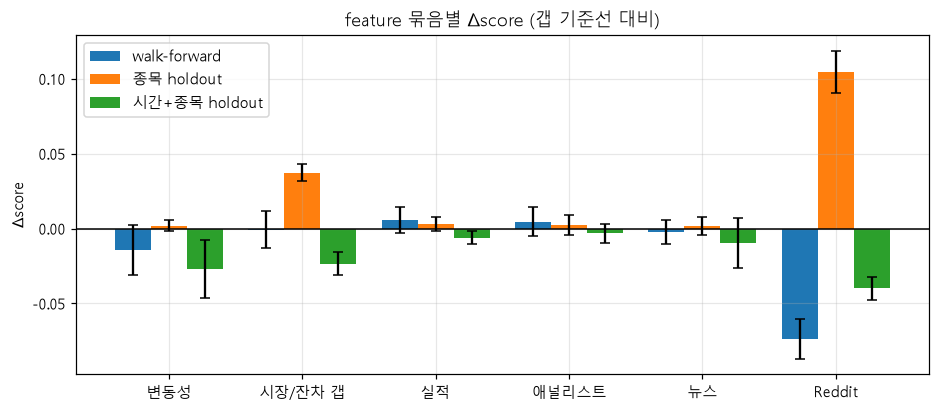

In [4]:
g = res[res["group"] != "기준선"].groupby(["group", "kind"])["d_score"].agg(["mean", "std"]).unstack()
order = list(groups)
kinds = ["wf", "sym", "time+sym"]
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(10, 4))
for i, (kd, lab) in enumerate(zip(kinds, ["walk-forward", "종목 holdout", "시간+종목 holdout"])):
    ax.bar(x + (i - 1) * 0.27, g[("mean", kd)].reindex(order), 0.27,
           yerr=g[("std", kd)].reindex(order), capsize=3, label=lab)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(x, order)
ax.set(title="feature 묶음별 Δscore (갭 기준선 대비)", ylabel="Δscore")
ax.legend()
plt.show()

## 3. feature 선택 표

계획서의 표와 같은 형식임. **시간 + 종목 holdout에서 Δscore가 양수이고 안정적인 것만** 모델링에 가져감.

In [5]:
agg = res.groupby("group").agg(solo=("solo", "mean"), with_base=("with_base", "mean"),
                               d_score=("d_score", "mean"), flip_rate=("flip_rate", "mean"))
ts = res[res["kind"] == "time+sym"].groupby("group")["d_score"]
agg["새 종목 Δscore"] = ts.mean()
agg["안정성(양수 비율)"] = (res.assign(pos=res["d_score"] > 0).groupby("group")["pos"].mean())
agg["채택"] = np.where((agg["새 종목 Δscore"] > 0) & (agg["안정성(양수 비율)"] >= 0.6), "O", "")
agg.loc[["기준선", *groups]].round(4)

,solo,with_base,d_score,flip_rate,새 종목 Δscore,안정성(양수 비율),채택
group,,,,,,,
기준선,0.4739,0.4739,0.0000,0.1768,0.0000,0.0000,
변동성,-0.0056,0.4609,-0.0130,0.2245,-0.0270,0.4615,
시장/잔차 갭,0.4680,0.4791,0.0051,0.1599,-0.0235,0.4615,
실적,0.0058,0.4741,0.0002,0.1773,-0.0060,0.3846,
애널리스트,-0.0011,0.4746,0.0007,0.2033,-0.0032,0.4615,
뉴스,0.0040,0.4704,-0.0035,0.1726,-0.0096,0.5385,
Reddit,0.1262,0.4817,0.0078,0.1245,-0.0400,0.3846,


## 4. 누적 ablation

채택된 묶음을 기준선에 하나씩 더하면서 시간 + 종목 holdout 점수가 어떻게 변하는지 봄.
선 그래프(line chart)로 그려 어느 단계에서 점수가 오르고 멈추는지 확인함.

,추가,score,std
0,(갭 기준선),0.5089,0.0239


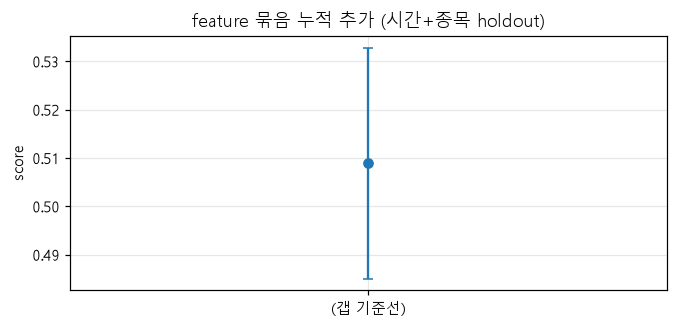

In [6]:
picked = [g for g in groups if agg.loc[g, "채택"] == "O"]
ts_splits = [s for s in splits if s[0].startswith("time+sym")]
feats, steps = list(base), []
for g in ["(갭 기준선)", *picked]:
    if g in groups:
        feats += groups[g]
    sc = [U.fit_eval(panel[tr], panel[te], feats)["score"] for _, tr, te in ts_splits]
    steps.append({"추가": g, "score": np.mean(sc), "std": np.std(sc)})
steps = pd.DataFrame(steps)
display(steps)
fig, ax = plt.subplots(figsize=(7, 3))
ax.errorbar(steps["추가"], steps["score"], yerr=steps["std"], marker="o", capsize=3)
ax.set(title="feature 묶음 누적 추가 (시간+종목 holdout)", ylabel="score")
plt.show()